In [1]:
train_path = '/content/UNSW_NB15_training-set.parquet'
test_path = '/content/UNSW_NB15_testing-set.parquet'

In [2]:
# PART 1: ADVANCED EDA - UNSW-NB15
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Plot aesthetics
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# Step 1: Load Data
train_path = '/content/UNSW_NB15_training-set.parquet'
test_path = '/content/UNSW_NB15_testing-set.parquet'

df_train = pd.read_parquet(train_path)
df_test = pd.read_parquet(test_path)

In [5]:
# Combine both for EDA
df_full = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

In [6]:
# Step 2: Quick Overview
print("Shape of Combined Data:", df_full.shape)
print("Columns:\n", df_full.columns.tolist())
print("Data Types:\n", df_full.dtypes.value_counts())
print("\nMissing Values:\n", df_full.isnull().sum().sort_values(ascending=False).head())

Shape of Combined Data: (257673, 36)
Columns:
 ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']
Data Types:
 float32     11
int16        9
int8         7
int32        3
int64        2
object       2
category     1
category     1
Name: count, dtype: int64

Missing Values:
 dur        0
proto      0
service    0
state      0
spkts      0
dtype: int64


In [7]:
# Step 3: Target Columns
print("\nBinary Label Distribution:")
print(df_full['label'].value_counts())

print("\nAttack Category Distribution:")
print(df_full['attack_cat'].value_counts(dropna=False))


Binary Label Distribution:
label
1    164673
0     93000
Name: count, dtype: int64

Attack Category Distribution:
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


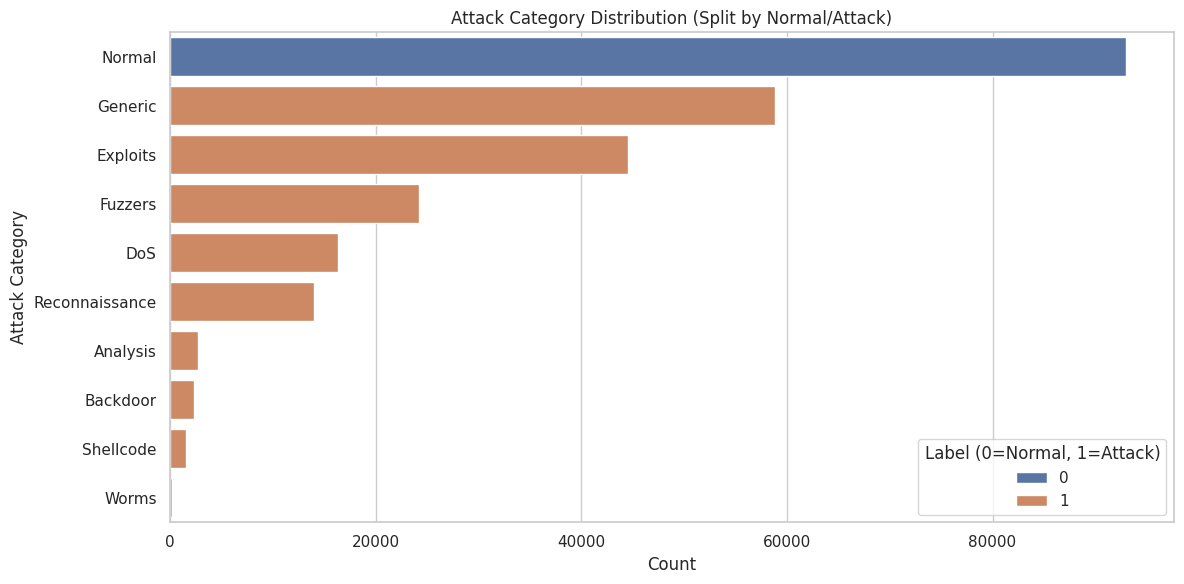

In [8]:
# Step 4: Attack Category by Binary Label
plt.figure(figsize=(12,6))
sns.countplot(data=df_full, y='attack_cat', hue='label', order=df_full['attack_cat'].value_counts().index)
plt.title("Attack Category Distribution (Split by Normal/Attack)")
plt.xlabel("Count")
plt.ylabel("Attack Category")
plt.legend(title='Label (0=Normal, 1=Attack)')
plt.tight_layout()
plt.show()

In [9]:
# Step 5: Top Protocols, Services, States by Attack
top_protos = df_full['proto'].value_counts().head(10)
top_services = df_full['service'].value_counts().head(10)
top_states = df_full['state'].value_counts().head(10)

print("\nTop Protocols:\n", top_protos)
print("\nTop Services:\n", top_services)
print("\nTop States:\n", top_states)


Top Protocols:
 proto
tcp     123041
udp      92701
unas     15599
arp       3846
ospf      3271
sctp      1474
any        396
gre        313
rsvp       264
ipv6       262
Name: count, dtype: int64

Top Services:
 service
-           141321
dns          68661
http         27011
smtp          6909
ftp-data      5391
ftp           4980
pop3          1528
ssh           1506
dhcp           120
snmp           109
Name: count, dtype: int64

Top States:
 state
FIN    117164
INT    116438
CON     20134
REQ      3833
RST        84
ECO        12
ACC         4
PAR         1
URN         1
no          1
Name: count, dtype: int64


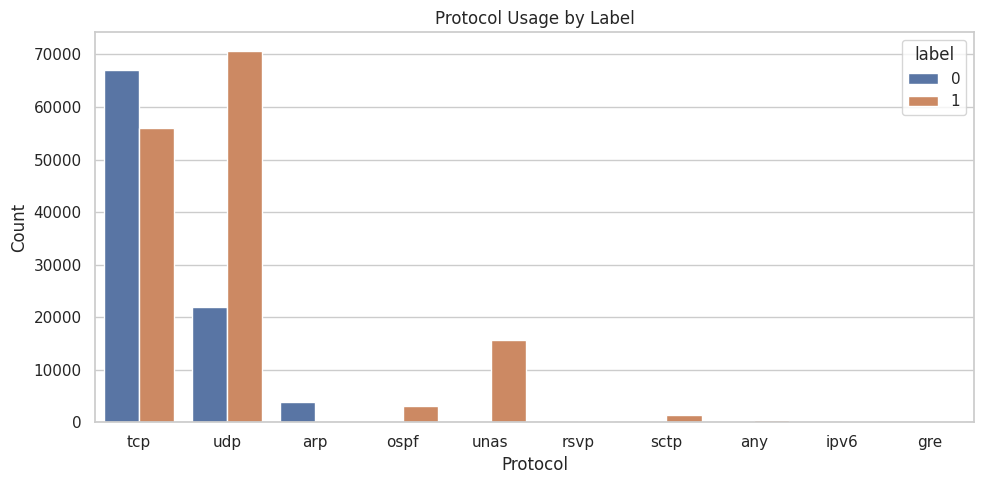

In [10]:
# Step 6: Plot top protocols vs label
plt.figure(figsize=(10,5))
sns.countplot(data=df_full[df_full['proto'].isin(top_protos.index)], x='proto', hue='label')
plt.title("Protocol Usage by Label")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
df_full.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')

In [12]:
# Step 7: Feature Summary
numerical_features = df_full.select_dtypes(include=['int64', 'float64'])
print("\nNumerical Feature Summary:\n")
print(numerical_features.describe().T[['mean', 'std', 'min', 'max']].round(2))


Numerical Feature Summary:

               mean           std  min           max
stcpb  1.006120e+09  1.367795e+09  0.0  4.294959e+09
dtcpb  1.002295e+09  1.363877e+09  0.0  4.294882e+09


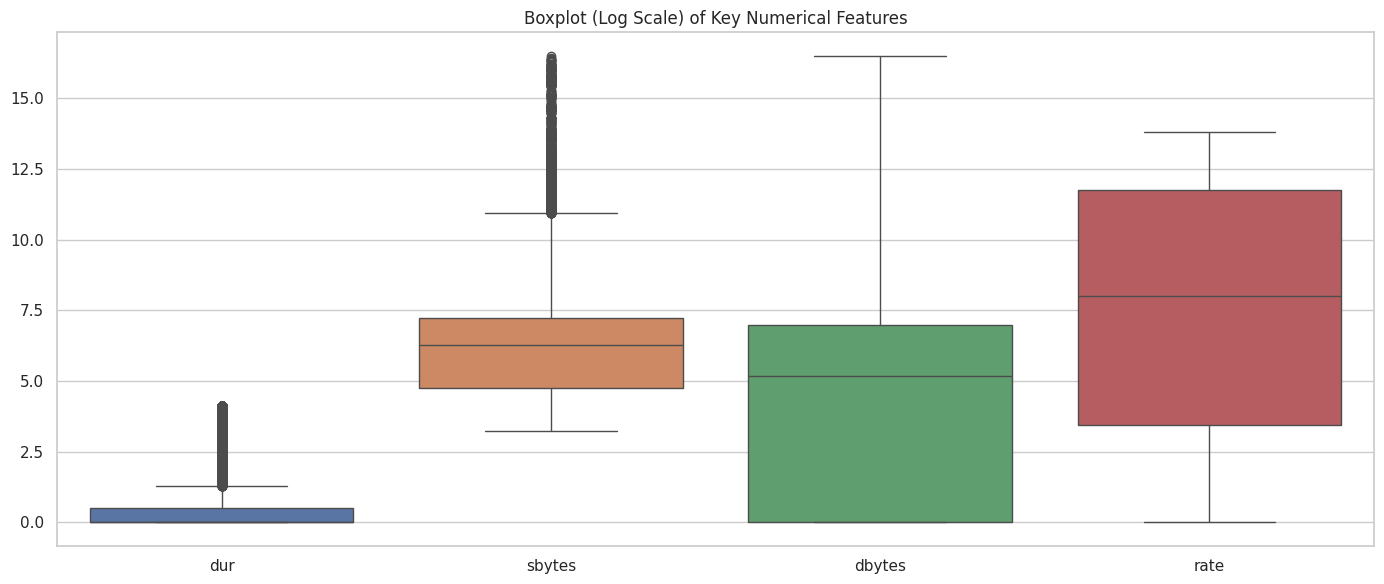

In [13]:
# Step 9: Boxplot (Log scale) for outlier detection
plt.figure(figsize=(14,6))
sns.boxplot(data=np.log1p(df_full[['dur', 'sbytes', 'dbytes', 'rate']]))
plt.title("Boxplot (Log Scale) of Key Numerical Features")
plt.tight_layout()
plt.show()


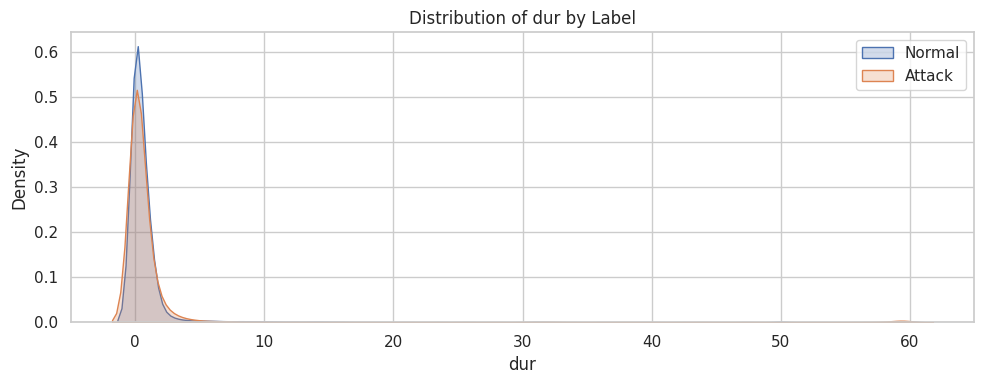

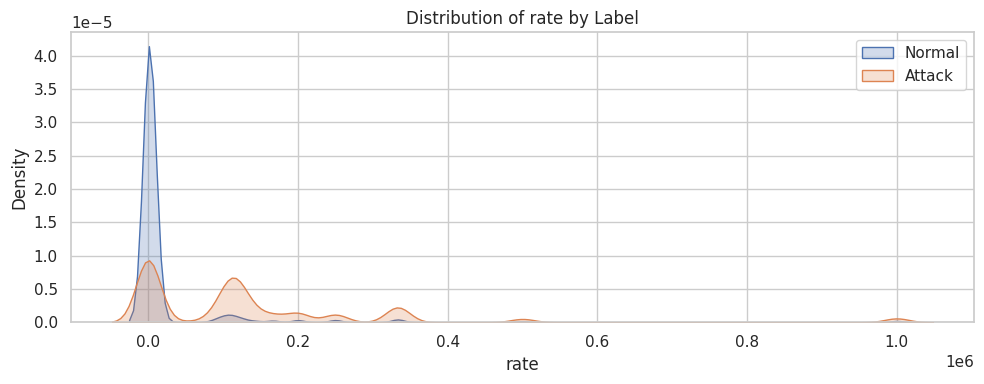

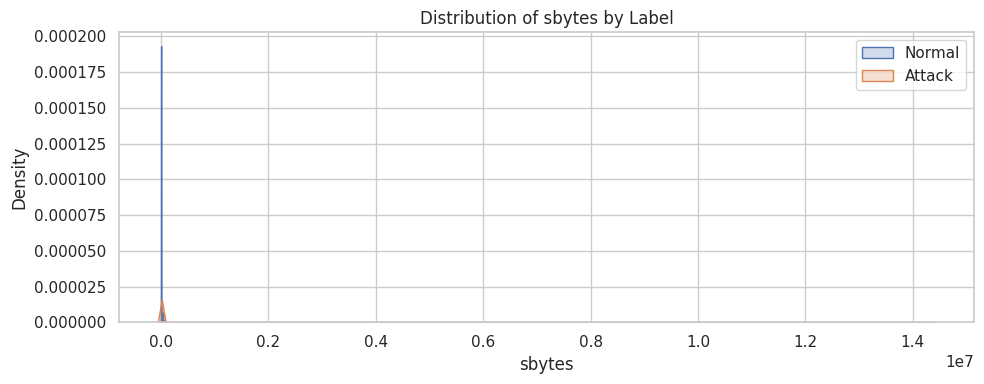

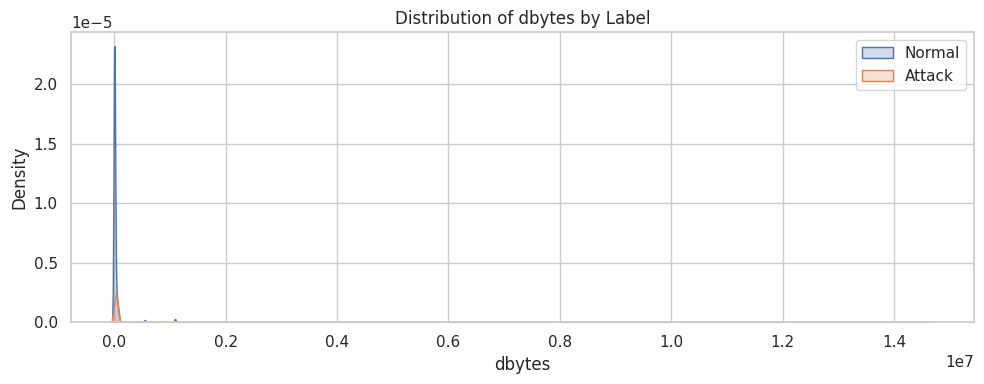

In [14]:
# Step 10: KDE for Traffic Features (normal vs attack)
for feature in ['dur', 'rate', 'sbytes', 'dbytes']:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df_full[df_full['label'] == 0], x=feature, label='Normal', fill=True)
    sns.kdeplot(data=df_full[df_full['label'] == 1], x=feature, label='Attack', fill=True)
    plt.title(f'Distribution of {feature} by Label')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode categorical variables (proto, service, state)
categorical_cols = ['proto', 'service', 'state']
encoded_df = df_full.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])
    label_encoders[col] = le
    print(f"{col} encoded — {len(le.classes_)} unique values")


proto encoded — 133 unique values
service encoded — 13 unique values
state encoded — 11 unique values


In [16]:
# Step 2: Drop non-predictive identifiers (if any)
cols_to_drop = ['id', 'attack_cat'] if 'id' in encoded_df.columns else ['attack_cat']
encoded_df = encoded_df.drop(columns=cols_to_drop, errors='ignore')

In [17]:
# Step 3: Encode target variable (label: 0 = Normal, 1 = Attack)
y_binary = encoded_df['label']
X_full = encoded_df.drop(columns=['label'])

In [18]:
# Step 4: Optional — Encode attack categories for multi-class target
# Only do this if you plan multi-class later
if 'attack_cat' in df_full.columns:
    attack_le = LabelEncoder()
    df_full['attack_cat_encoded'] = attack_le.fit_transform(df_full['attack_cat'].astype(str))
    y_multiclass = df_full['attack_cat_encoded']
    print("\nEncoded attack_cat classes:\n", dict(zip(attack_le.classes_, attack_le.transform(attack_le.classes_))))


Encoded attack_cat classes:
 {'Analysis': np.int64(0), 'Backdoor': np.int64(1), 'DoS': np.int64(2), 'Exploits': np.int64(3), 'Fuzzers': np.int64(4), 'Generic': np.int64(5), 'Normal': np.int64(6), 'Reconnaissance': np.int64(7), 'Shellcode': np.int64(8), 'Worms': np.int64(9)}


In [19]:
# Step 5: Optional — Risk Mapping (based on attack severity)
risk_map = {
    'Normal': 'Low',
    'Fuzzers': 'Medium', 'Reconnaissance': 'Medium',
    'Analysis': 'High', 'Backdoor': 'High', 'Shellcode': 'High', 'Worms': 'High',
    'DoS': 'High', 'Exploits': 'High', 'Generic': 'Medium'
}

# Fill risk for all rows (NaN for Normal automatically becomes 'Low')
df_full['risk'] = df_full['attack_cat'].map(risk_map).fillna('Low')

In [20]:
# Step 6: Binary Risk Encoding (for alerting systems)
df_full['risk_level'] = df_full['risk'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Step 7: Final data preview
print("\nFinal encoded shape:", X_full.shape)
print("\nSample rows with risk mapping:")
print(df_full[['attack_cat', 'risk', 'risk_level']].drop_duplicates())


Final encoded shape: (257673, 34)

Sample rows with risk mapping:
            attack_cat    risk  risk_level
0               Normal     Low           0
47911         Backdoor    High           2
47932         Analysis    High           2
48017          Fuzzers  Medium           1
48813        Shellcode    High           2
48866   Reconnaissance  Medium           1
48932         Exploits    High           2
48999              DoS    High           2
49959            Worms    High           2
117204         Generic  Medium           1


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Split back into train and test using original index (already labeled from parquet)
X = X_full.copy()
y = y_binary.copy()

In [22]:
# Ensure alignment
X['label'] = y.values
X['risk'] = df_full['risk'].values
X['risk_level'] = df_full['risk_level'].values

# Use original files to split
train_len = len(pd.read_parquet('/content/UNSW_NB15_training-set.parquet'))
X_train = X.iloc[:train_len].drop(columns=['label', 'risk', 'risk_level'])
X_test = X.iloc[train_len:].drop(columns=['label', 'risk', 'risk_level'])
y_train = y[:train_len]
y_test = y[train_len:]
risk_test = df_full['risk'][train_len:]
attack_type_test = df_full['attack_cat'][train_len:]

In [23]:
# Step 2: Train a Random Forest
clf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [24]:
# Step 3: Predict
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

In [25]:
# Step 4: Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.69      0.80     37000
           1       0.79      0.98      0.88     45332

    accuracy                           0.85     82332
   macro avg       0.88      0.83      0.84     82332
weighted avg       0.87      0.85      0.84     82332


Confusion Matrix:
 [[25423 11577]
 [  795 44537]]

ROC AUC Score: 0.9792536913844047


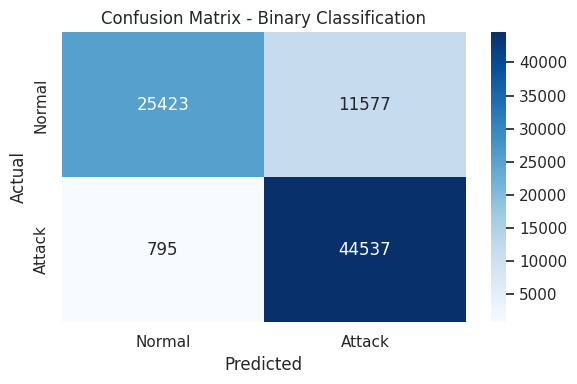

In [26]:
# Step 5: Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Binary Classification")
plt.tight_layout()
plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prepare comparison table
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{name} Evaluation:")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC AUC:", round(auc, 4))

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': auc
    }

# Initialize models
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Evaluate all models
results = []
results.append(evaluate_model("Random Forest", clf, X_train, y_train, X_test, y_test))
results.append(evaluate_model("Logistic Regression", logreg, X_train, y_train, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test))

# Show results comparison
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison Table:")
print(results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True))


Random Forest Evaluation:
Accuracy: 0.8497
Precision: 0.7937
Recall: 0.9825
F1 Score: 0.878
ROC AUC: 0.9793

Logistic Regression Evaluation:
Accuracy: 0.7061
Precision: 0.6613
Recall: 0.9559
F1 Score: 0.7818
ROC AUC: 0.8171


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:41:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Evaluation:
Accuracy: 0.8711
Precision: 0.8241
Recall: 0.9738
F1 Score: 0.8927
ROC AUC: 0.9801

📊 Model Comparison Table:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0              XGBoost  0.871132   0.824093  0.973815  0.892720  0.980052
1        Random Forest  0.849730   0.793688  0.982463  0.878043  0.979254
2  Logistic Regression  0.706117   0.661260  0.955947  0.781755  0.817105


<ipython-input-28-665d1347d250>:24: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


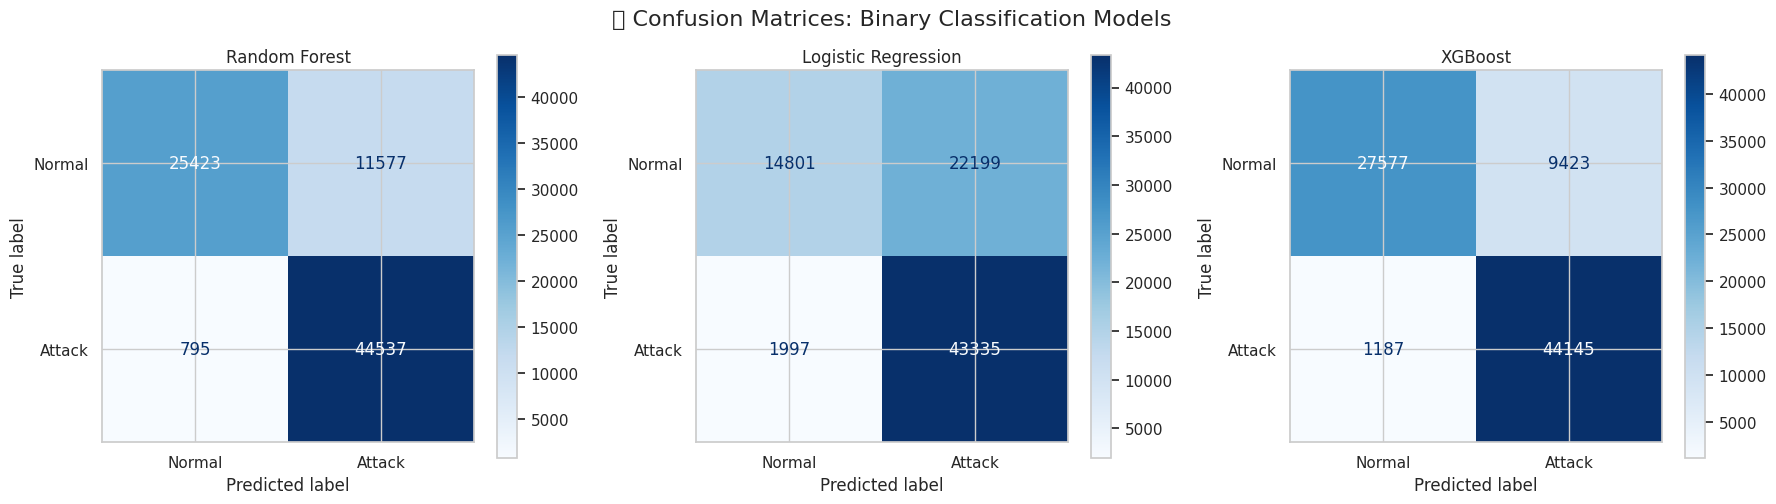

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Predict with all models
y_pred_rf = clf.predict(X_test)
y_pred_lr = logreg.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# Step 2: Plot confusion matrices
models = {
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "XGBoost": y_pred_xgb
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    ax.set_title(model_name)

plt.suptitle("🔍 Confusion Matrices: Binary Classification Models", fontsize=16)
plt.tight_layout()
plt.show()

In [29]:
# Step 1: Select random attack + normal rows from test set
sample_attacks = X_test[y_test.values == 1].sample(2, random_state=1)
sample_normals = X_test[y_test.values == 0].sample(2, random_state=2)

# Combine into one small batch
sample_input = pd.concat([sample_attacks, sample_normals]).reset_index(drop=True)

# Step 2: Predict using Random Forest (you can switch to xgb or logreg if needed)
sample_pred = clf.predict(sample_input)
sample_proba = clf.predict_proba(sample_input)[:, 1]

# Step 3: Match with original details: risk + attack type (already stored in df_full)
# Reuse the same test indices
sample_indices = sample_input.index
full_test_df = df_full.iloc[train_len:].reset_index(drop=True)
sample_risks = full_test_df.loc[sample_indices, 'risk'].values
sample_attacks = full_test_df.loc[sample_indices, 'attack_cat'].values

# Step 4: Generate full response table
response_map = {
    'Low': 'Allow',
    'Medium': 'Alert + Monitor',
    'High': 'Alert + Block'
}

df_sample_results = pd.DataFrame({
    'Predicted_Label': sample_pred,
    'Attack_Category': sample_attacks,
    'Risk': sample_risks,
    'Confidence (Attack)': sample_proba,
})

df_sample_results['Suggested_Action'] = df_sample_results['Risk'].map(response_map)

# Step 5: Show results
print("\n🚦 Real-Time Sample Predictions:")
print(df_sample_results)


🚦 Real-Time Sample Predictions:
   Predicted_Label Attack_Category Risk  Confidence (Attack) Suggested_Action
0                1          Normal  Low             1.000000            Allow
1                1          Normal  Low             0.999999            Allow
2                1          Normal  Low             0.659155            Allow
3                0          Normal  Low             0.000017            Allow


In [30]:
def predict_realtime_traffic(input_data, model, label_encoders, reference_columns, threshold=0.5):
    """
    Real-time prediction function with safe column handling.

    Parameters:
        input_data (dict): Dictionary of input features.
        model: Trained classifier.
        label_encoders (dict): Encoders for categorical features.
        reference_columns (list): Column names used during model training.
        threshold (float): Attack probability threshold.

    Returns:
        dict: Prediction label, confidence, and suggested action.
    """
    import pandas as pd

    # Convert to single-row DataFrame
    df = pd.DataFrame([input_data])

    # Encode categorical features safely
    for col in ['proto', 'service', 'state']:
        if col in df.columns:
            le = label_encoders[col]
            df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # Ensure all expected columns are present
    for col in reference_columns:
        if col not in df.columns:
            df[col] = 0  # default value for missing columns

    # Reorder columns to match training
    df = df[reference_columns]

    # Predict
    pred_prob = model.predict_proba(df)[0][1]
    pred_label = int(pred_prob >= threshold)

    # Map label to action
    if pred_label == 1 and pred_prob >= 0.9:
        action = "Alert + Block"
    elif pred_label == 1:
        action = "Alert + Monitor"
    else:
        action = "Allow"

    return {
        "Predicted_Label": "Attack" if pred_label == 1 else "Normal",
        "Confidence": round(pred_prob, 4),
        "Suggested_Action": action
    }

In [31]:
# Reference columns from training
reference_columns = X_train.columns.tolist()

# Your sample input
sample_input = {
    'dur': 0.5, 'proto': 'tcp', 'service': 'http', 'state': 'FIN',
    'spkts': 10, 'dpkts': 12, 'sbytes': 560, 'dbytes': 890,
    'rate': 120.0, 'sload': 2500.0, 'dload': 1500.0, 'sttl': 64, 'dttl': 63,
    'sloss': 0, 'dloss': 0, 'sinpkt': 0.01, 'dinpkt': 0.02,
    'sjit': 0.0, 'djit': 0.0, 'swin': 255, 'dwin': 255,
    'stcpb': 0, 'dtcpb': 0, 'tcprtt': 0.1, 'synack': 0.1, 'ackdat': 0.1,
    'smean': 60, 'dmean': 90, 'trans_depth': 0, 'response_body_len': 0,
    'ct_src_dport_ltm': 1, 'ct_dst_sport_ltm': 1,
    'is_ftp_login': 0, 'ct_ftp_cmd': 0, 'ct_flw_http_mthd': 0,
    'is_sm_ips_ports': 0
}

# Call updated real-time function
result = predict_realtime_traffic(sample_input, clf, label_encoders, reference_columns)
print("🚨 Real-Time Prediction Result:")
print(result)

🚨 Real-Time Prediction Result:
{'Predicted_Label': 'Attack', 'Confidence': np.float64(0.6385), 'Suggested_Action': 'Alert + Monitor'}


In [32]:
pip install shap

In [33]:
import shap

# Preload SHAP explainer globally for speed (for tree models)
explainer = shap.TreeExplainer(clf)

def predict_realtime_with_shap(input_data, model, label_encoders, reference_columns, explainer, threshold=0.5):
    """
    Real-time prediction with SHAP-based feature explanation (top 3).

    Parameters:
        input_data (dict): Dictionary of feature values.
        model: Trained model.
        label_encoders: Dict of label encoders for categorical columns.
        reference_columns: List of columns used during training.
        explainer: Pre-initialized SHAP TreeExplainer object.
        threshold: Classification threshold for attack.

    Returns:
        dict: Label, confidence, suggested action, top 3 influential features
    """
    import pandas as pd

    # Step 1: Prepare input DataFrame
    df = pd.DataFrame([input_data])

    for col in ['proto', 'service', 'state']:
        if col in df.columns:
            le = label_encoders[col]
            df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    for col in reference_columns:
        if col not in df.columns:
            df[col] = 0

    df = df[reference_columns]

    # Step 2: Predict
    pred_prob = model.predict_proba(df)[0][1]
    pred_label = int(pred_prob >= threshold)

    # Step 3: Suggested action
    if pred_label == 1 and pred_prob >= 0.9:
        action = "Alert + Block"
    elif pred_label == 1:
        action = "Alert + Monitor"
    else:
        action = "Allow"

    # Step 4: SHAP values for explanation
    shap_values = explainer.shap_values(df)
    shap_contrib = shap_values[1] if isinstance(shap_values, list) else shap_values[0]

    feature_impact = list(zip(df.columns, shap_contrib[0]))
    top3 = sorted(feature_impact, key=lambda x: abs(x[1]), reverse=True)[:3]
    top_features = [{ "feature": f, "impact": round(v, 4)} for f, v in top3]

    return {
        "Predicted_Label": "Attack" if pred_label == 1 else "Normal",
        "Confidence": round(pred_prob, 4),
        "Suggested_Action": action,
        "Top_3_Influential_Features": top_features
    }

In [34]:
result = predict_realtime_with_shap(sample_input, clf, label_encoders, reference_columns, explainer)
print("🚨 Real-Time Prediction + Explainability:")
print(result)

🚨 Real-Time Prediction + Explainability:
{'Predicted_Label': 'Attack', 'Confidence': np.float64(0.6385), 'Suggested_Action': 'Alert + Monitor', 'Top_3_Influential_Features': [{'feature': 'proto', 'impact': np.float64(0.004)}, {'feature': 'dur', 'impact': np.float64(-0.004)}]}


<ipython-input-35-81de03b1faa1>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


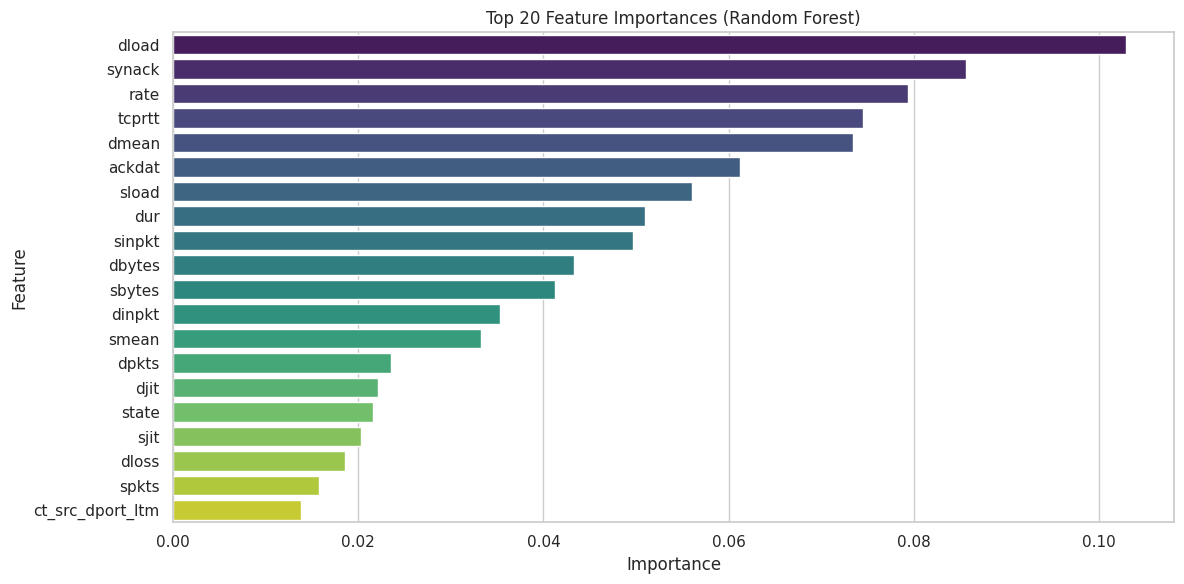

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from trained model
importances = clf.feature_importances_
features = X_train.columns

# Create DataFrame
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()